In [2]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

Torch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
VRAM (GB): 14.56


In [3]:
%cd /content
!rm -rf /content/void-model
!git clone https://github.com/Netflix/void-model.git
!ls /content/void-model


/content
Cloning into 'void-model'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 297 (delta 77), reused 83 (delta 59), pack-reused 188 (from 2)
Receiving objects: 100% (297/297), 35.00 MiB | 18.27 MiB/s, done.
Resolving deltas: 100% (107/107), done.
assets		 datasets   notebook.ipynb    sample	  VLM-MASK-REASONER
config		 inference  README.md	      scripts
data_generation  LICENSE    requirements.txt  videox_fun


In [4]:
%cd /content/void-model
!python -m pip install -q --upgrade pip
!python -m pip install -q scikit-image mediapy imageio imageio-ffmpeg lpips loguru einops opencv-python

/content/void-model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.0 MB/s eta 0:00:00


In [5]:
from pathlib import Path

repo = Path("/content/void-model")
module_path = repo / "videox_fun" / "utils" / "temporal_metrics.py"
module_path.parent.mkdir(parents=True, exist_ok=True)

temporal_metrics_py = r'''import csv
import json
import math
import os
from typing import Any, Dict, List, Optional

import numpy as np
import torch
import torch.nn.functional as F
from loguru import logger
from skimage.metrics import structural_similarity

from videox_fun.utils.optical_flow_utils import RAFTFlowExtractor


def normalize_video_for_metrics(video: torch.Tensor, valid_frames: Optional[int] = None) -> torch.Tensor:
    if video.ndim == 5:
        video = video[0]
    if video.ndim != 4:
        raise ValueError(f"Expected [B,C,T,H,W] or [C,T,H,W], got shape {tuple(video.shape)}")

    if video.shape[0] != 3 and video.shape[1] == 3:
        video = video.permute(1, 0, 2, 3)
    if video.shape[0] != 3:
        raise ValueError(f"Expected RGB channels, got shape {tuple(video.shape)}")

    frames = video.detach().float().permute(1, 0, 2, 3).contiguous()
    if valid_frames is not None:
        frames = frames[:valid_frames]

    if frames.numel() == 0:
        raise ValueError("Video has no frames after normalization")

    if frames.max() > 1.5:
        frames = frames / 255.0
    elif frames.min() < 0.0:
        frames = (frames + 1.0) / 2.0

    return frames.clamp(0.0, 1.0)


def _compute_psnr(frame1: np.ndarray, frame2: np.ndarray) -> float:
    mse = float(np.mean((frame1 - frame2) ** 2))
    mse = max(mse, 1e-10)
    return float(10.0 * math.log10(1.0 / mse))


def _normalized_base_grid(height: int, width: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    y_coords = torch.linspace(-1.0, 1.0, steps=height, device=device, dtype=dtype)
    x_coords = torch.linspace(-1.0, 1.0, steps=width, device=device, dtype=dtype)
    grid_y, grid_x = torch.meshgrid(y_coords, x_coords, indexing="ij")
    return torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)


def backward_warp(frame: torch.Tensor, backward_flow: torch.Tensor) -> torch.Tensor:
    _, _, height, width = frame.shape
    base_grid = _normalized_base_grid(height, width, frame.device, frame.dtype)

    flow_x = backward_flow[:, 0] * (2.0 / max(width - 1, 1))
    flow_y = backward_flow[:, 1] * (2.0 / max(height - 1, 1))
    flow_grid = torch.stack((flow_x, flow_y), dim=-1)
    sample_grid = base_grid + flow_grid

    return F.grid_sample(
        frame,
        sample_grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=True,
    )


def summarize_pair_metrics(pair_metrics: List[Dict[str, float]]) -> Dict[str, float]:
    metric_names = [
        "lpips_temporal",
        "optical_flow_consistency_l1",
        "psnr_consecutive",
        "ssim_consecutive",
    ]
    summary: Dict[str, float] = {}

    for metric_name in metric_names:
        values = [float(pair[metric_name]) for pair in pair_metrics]
        if not values:
            continue
        array = np.asarray(values, dtype=np.float64)
        summary[f"{metric_name}_mean"] = float(array.mean())
        summary[f"{metric_name}_std"] = float(array.std())
        summary[f"{metric_name}_min"] = float(array.min())
        summary[f"{metric_name}_max"] = float(array.max())

    summary["num_pairs"] = len(pair_metrics)
    return summary


class TemporalMetricsEvaluator:
    def __init__(
        self,
        device: Optional[str] = None,
        lpips_model: Optional[torch.nn.Module] = None,
        flow_extractor: Optional[RAFTFlowExtractor] = None,
    ) -> None:
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self._lpips_model = lpips_model
        self._flow_extractor = flow_extractor

    def _get_lpips_model(self) -> torch.nn.Module:
        if self._lpips_model is None:
            import lpips
            self._lpips_model = lpips.LPIPS(net="alex").to(self.device)
            self._lpips_model.eval()
        return self._lpips_model

    def _get_flow_extractor(self) -> RAFTFlowExtractor:
        if self._flow_extractor is None:
            self._flow_extractor = RAFTFlowExtractor(device=self.device)
        return self._flow_extractor

    def _compute_pair_metrics(self, frame1: torch.Tensor, frame2: torch.Tensor) -> Dict[str, float]:
        frame1_cpu = frame1.detach().cpu()
        frame2_cpu = frame2.detach().cpu()
        frame1_np = frame1_cpu.permute(1, 2, 0).numpy()
        frame2_np = frame2_cpu.permute(1, 2, 0).numpy()

        psnr = _compute_psnr(frame1_np, frame2_np)

        min_hw = min(frame1_np.shape[0], frame1_np.shape[1])
        win_size = min(7, min_hw)
        if win_size % 2 == 0:
            win_size -= 1
        if win_size < 3:
            win_size = 3

        ssim = float(
            structural_similarity(
                frame1_np,
                frame2_np,
                channel_axis=2,
                data_range=1.0,
                win_size=win_size,
            )
        )

        lpips_model = self._get_lpips_model()
        lpips_input_1 = frame1.unsqueeze(0).to(self.device) * 2.0 - 1.0
        lpips_input_2 = frame2.unsqueeze(0).to(self.device) * 2.0 - 1.0
        with torch.no_grad():
            lpips_value = float(lpips_model(lpips_input_1, lpips_input_2).mean().item())

        flow_extractor = self._get_flow_extractor()
        flow_frame1 = frame1.unsqueeze(0).to(self.device)
        flow_frame2 = frame2.unsqueeze(0).to(self.device)
        with torch.no_grad():
            backward_flow = flow_extractor.extract_flow(flow_frame2, flow_frame1)
            warped_frame1 = backward_warp(flow_frame1, backward_flow)
            valid_mask = backward_warp(
                torch.ones((1, 1, frame1.shape[1], frame1.shape[2]), device=self.device, dtype=flow_frame1.dtype),
                backward_flow,
            )

        diff = torch.abs(warped_frame1 - flow_frame2)
        valid_pixels = valid_mask > 0.5
        if valid_pixels.any():
            flow_consistency = float(diff.masked_select(valid_pixels.expand_as(diff)).mean().item())
        else:
            flow_consistency = float(diff.mean().item())

        return {
            "lpips_temporal": lpips_value,
            "optical_flow_consistency_l1": flow_consistency,
            "psnr_consecutive": psnr,
            "ssim_consecutive": ssim,
        }

    def evaluate(
        self,
        video: torch.Tensor,
        *,
        video_name: Optional[str] = None,
        stage: Optional[str] = None,
        fps: Optional[int] = None,
        valid_frames: Optional[int] = None,
    ) -> Dict[str, Any]:
        frames = normalize_video_for_metrics(video, valid_frames=valid_frames)
        if frames.shape[0] < 2:
            raise ValueError("Temporal metrics require at least two frames")

        pair_metrics: List[Dict[str, float]] = []
        for index in range(frames.shape[0] - 1):
            metrics = self._compute_pair_metrics(frames[index], frames[index + 1])
            pair_metrics.append({
                "t": index,
                "t_next": index + 1,
                **metrics,
            })

        return {
            "video_name": video_name,
            "stage": stage,
            "num_frames": int(frames.shape[0]),
            "num_pairs": int(frames.shape[0] - 1),
            "fps": fps,
            "summary": summarize_pair_metrics(pair_metrics),
            "pairs": pair_metrics,
        }

    @staticmethod
    def format_summary(result: Dict[str, Any]) -> str:
        summary = result["summary"]
        video_name = result.get("video_name") or "video"
        stage = result.get("stage") or "temporal_eval"
        return (
            f"[temporal_eval] {video_name} {stage} | pairs={summary['num_pairs']} | "
            f"lpips={summary['lpips_temporal_mean']:.4f} | "
            f"ofc_l1={summary['optical_flow_consistency_l1_mean']:.4f} | "
            f"psnr={summary['psnr_consecutive_mean']:.2f} | "
            f"ssim={summary['ssim_consecutive_mean']:.4f}"
        )

    @staticmethod
    def write(result: Dict[str, Any], output_prefix: str) -> Dict[str, str]:
        json_path = f"{output_prefix}_temporal_metrics.json"
        csv_path = f"{output_prefix}_temporal_metrics_pairs.csv"
        os.makedirs(os.path.dirname(json_path), exist_ok=True)

        with open(json_path, "w", encoding="utf-8") as json_file:
            json.dump(result, json_file, indent=2)

        with open(csv_path, "w", newline="", encoding="utf-8") as csv_file:
            fieldnames = [
                "video_name",
                "stage",
                "t",
                "t_next",
                "lpips_temporal",
                "optical_flow_consistency_l1",
                "psnr_consecutive",
                "ssim_consecutive",
            ]
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
            writer.writeheader()
            for pair in result["pairs"]:
                writer.writerow({
                    "video_name": result.get("video_name"),
                    "stage": result.get("stage"),
                    **pair,
                })

        logger.info(TemporalMetricsEvaluator.format_summary(result))
        return {"json": json_path, "csv": csv_path}
'''

module_path.write_text(temporal_metrics_py, encoding="utf-8")
print("Módulo temporal_metrics.py criado.")

Módulo temporal_metrics.py criado.


In [6]:
from pathlib import Path

sample_video = Path("/content/void-model/sample/lime/input_video.mp4")
print("Existe?", sample_video.exists())
print(sample_video)

Existe? True
/content/void-model/sample/lime/input_video.mp4


In [7]:
from IPython.display import Video, display

video_path = "/content/void-model/sample/lime/input_video.mp4"
display(Video(video_path, embed=True, width=480))

In [8]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import mediapy as media

sys.path.insert(0, "/content/void-model")

video_path = "/content/void-model/sample/lime/input_video.mp4"
video_np = np.array(media.read_video(video_path))

print("Shape original:", video_np.shape)

video_np = video_np[:8]
video_tensor = torch.from_numpy(video_np).permute(3, 0, 1, 2).float() / 255.0
video_tensor = F.interpolate(video_tensor, size=(160, 160), mode="area").unsqueeze(0)

print("Shape processado:", tuple(video_tensor.shape))
print("Min/Max:", float(video_tensor.min()), float(video_tensor.max()))

Shape original: (46, 2160, 3840, 3)
Shape processado: (1, 3, 8, 160, 160)
Min/Max: 0.03445383161306381 0.928267240524292


In [9]:
from videox_fun.utils.temporal_metrics import TemporalMetricsEvaluator

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device usado:", device)

evaluator = TemporalMetricsEvaluator(device=device)

result = evaluator.evaluate(
    video_tensor,
    video_name="lime_input_video",
    stage="module_validation",
    fps=12,
)

print("Resumo bruto:")
print(result["summary"])
print()
print("Resumo formatado:")
print(evaluator.format_summary(result))

Device usado: cuda
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 175MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Downloading: "https://download.pytorch.org/models/raft_large_C_T_SKHT_V2-ff5fadd5.pth" to /root/.cache/torch/hub/checkpoints/raft_large_C_T_SKHT_V2-ff5fadd5.pth


100%|██████████| 20.1M/20.1M [00:00<00:00, 147MB/s]


Resumo bruto:
{'lpips_temporal_mean': 0.018937284126877785, 'lpips_temporal_std': 0.005050792815553074, 'lpips_temporal_min': 0.010238805785775185, 'lpips_temporal_max': 0.02637701854109764, 'optical_flow_consistency_l1_mean': 0.005620031883674008, 'optical_flow_consistency_l1_std': 0.0008413183694414083, 'optical_flow_consistency_l1_min': 0.004399414174258709, 'optical_flow_consistency_l1_max': 0.007065273821353912, 'psnr_consecutive_mean': 28.631973538030188, 'psnr_consecutive_std': 1.7263237460654204, 'psnr_consecutive_min': 26.26974161787008, 'psnr_consecutive_max': 31.695204692166136, 'ssim_consecutive_mean': 0.9253453697477069, 'ssim_consecutive_std': 0.023402245107647324, 'ssim_consecutive_min': 0.8841662406921387, 'ssim_consecutive_max': 0.9598162174224854, 'num_pairs': 7}

Resumo formatado:
[temporal_eval] lime_input_video module_validation | pairs=7 | lpips=0.0189 | ofc_l1=0.0056 | psnr=28.63 | ssim=0.9253


In [10]:
from pathlib import Path

output_prefix = "/content/temporal_metrics_demo/lime_input_video"
Path("/content/temporal_metrics_demo").mkdir(parents=True, exist_ok=True)

paths = evaluator.write(result, output_prefix)

print(paths)

2026-05-06 03:44:48.428 | INFO     | videox_fun.utils.temporal_metrics:write:249 - [temporal_eval] lime_input_video module_validation | pairs=7 | lpips=0.0189 | ofc_l1=0.0056 | psnr=28.63 | ssim=0.9253


{'json': '/content/temporal_metrics_demo/lime_input_video_temporal_metrics.json', 'csv': '/content/temporal_metrics_demo/lime_input_video_temporal_metrics_pairs.csv'}


In [11]:
from pathlib import Path

out_dir = Path("/content/temporal_metrics_demo")
for f in sorted(out_dir.glob("*")):
    print(f.name)

lime_input_video_temporal_metrics.json
lime_input_video_temporal_metrics_pairs.csv


In [12]:
import json

json_path = "/content/temporal_metrics_demo/lime_input_video_temporal_metrics.json"
data = json.load(open(json_path, "r", encoding="utf-8"))

print(json.dumps(data, indent=2)[:3000])

{
  "video_name": "lime_input_video",
  "stage": "module_validation",
  "num_frames": 8,
  "num_pairs": 7,
  "fps": 12,
  "summary": {
    "lpips_temporal_mean": 0.018937284126877785,
    "lpips_temporal_std": 0.005050792815553074,
    "lpips_temporal_min": 0.010238805785775185,
    "lpips_temporal_max": 0.02637701854109764,
    "optical_flow_consistency_l1_mean": 0.005620031883674008,
    "optical_flow_consistency_l1_std": 0.0008413183694414083,
    "optical_flow_consistency_l1_min": 0.004399414174258709,
    "optical_flow_consistency_l1_max": 0.007065273821353912,
    "psnr_consecutive_mean": 28.631973538030188,
    "psnr_consecutive_std": 1.7263237460654204,
    "psnr_consecutive_min": 26.26974161787008,
    "psnr_consecutive_max": 31.695204692166136,
    "ssim_consecutive_mean": 0.9253453697477069,
    "ssim_consecutive_std": 0.023402245107647324,
    "ssim_consecutive_min": 0.8841662406921387,
    "ssim_consecutive_max": 0.9598162174224854,
    "num_pairs": 7
  },
  "pairs": [
   

In [13]:
import pandas as pd

csv_path = "/content/temporal_metrics_demo/lime_input_video_temporal_metrics_pairs.csv"
df = pd.read_csv(csv_path)
df.head()

,video_name,stage,t,t_next,lpips_temporal,optical_flow_consistency_l1,psnr_consecutive,ssim_consecutive
0,lime_input_video,module_validation,0,1,0.018251,0.005210,29.985402,0.950628
1,lime_input_video,module_validation,1,2,0.026377,0.007065,26.763021,0.909903
2,lime_input_video,module_validation,2,3,0.018869,0.005242,28.213467,0.920542
3,lime_input_video,module_validation,3,4,0.024850,0.006594,26.269742,0.884166
4,lime_input_video,module_validation,4,5,0.015484,0.004399,29.179057,0.931058


In [14]:
summary = data["summary"]

print("LPIPS temporal mean:", summary["lpips_temporal_mean"])
print("Optical Flow Consistency mean:", summary["optical_flow_consistency_l1_mean"])
print("PSNR mean:", summary["psnr_consecutive_mean"])
print("SSIM mean:", summary["ssim_consecutive_mean"])
print("Pairs:", summary["num_pairs"])

LPIPS temporal mean: 0.018937284126877785
Optical Flow Consistency mean: 0.005620031883674008
PSNR mean: 28.631973538030188
SSIM mean: 0.9253453697477069
Pairs: 7


In [15]:
print("Interpretacao:")
print("- LPIPS temporal: menor tende a indicar maior estabilidade perceptual entre frames.")
print("- Optical Flow Consistency: menor tende a indicar maior coerencia temporal.")
print("- PSNR: maior tende a indicar maior similaridade entre frames consecutivos.")
print("- SSIM: maior tende a indicar maior similaridade estrutural entre frames consecutivos.")

Interpretacao:
- LPIPS temporal: menor tende a indicar maior estabilidade perceptual entre frames.
- Optical Flow Consistency: menor tende a indicar maior coerencia temporal.
- PSNR: maior tende a indicar maior similaridade entre frames consecutivos.
- SSIM: maior tende a indicar maior similaridade estrutural entre frames consecutivos.


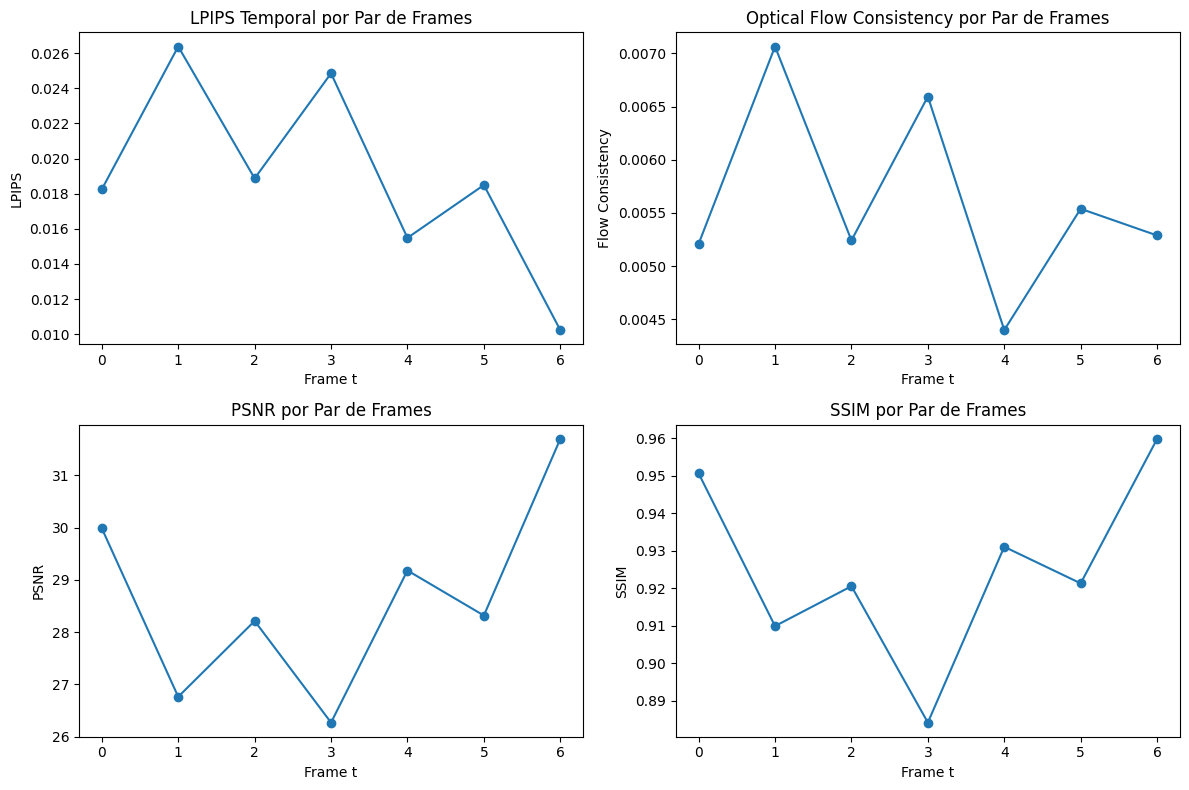

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

csv_path = "/content/temporal_metrics_demo/lime_input_video_temporal_metrics_pairs.csv"
df = pd.read_csv(csv_path)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(df["t"], df["lpips_temporal"], marker="o")
axes[0, 0].set_title("LPIPS Temporal por Par de Frames")
axes[0, 0].set_xlabel("Frame t")
axes[0, 0].set_ylabel("LPIPS")

axes[0, 1].plot(df["t"], df["optical_flow_consistency_l1"], marker="o")
axes[0, 1].set_title("Optical Flow Consistency por Par de Frames")
axes[0, 1].set_xlabel("Frame t")
axes[0, 1].set_ylabel("Flow Consistency")

axes[1, 0].plot(df["t"], df["psnr_consecutive"], marker="o")
axes[1, 0].set_title("PSNR por Par de Frames")
axes[1, 0].set_xlabel("Frame t")
axes[1, 0].set_ylabel("PSNR")

axes[1, 1].plot(df["t"], df["ssim_consecutive"], marker="o")
axes[1, 1].set_title("SSIM por Par de Frames")
axes[1, 1].set_xlabel("Frame t")
axes[1, 1].set_ylabel("SSIM")

plt.tight_layout()
plt.show()

In [17]:
summary = data["summary"]

print("Resumo final das métricas temporais")
print("-----------------------------------")
print(f"Video analisado: {data['video_name']}")
print(f"Stage: {data['stage']}")
print(f"Frames analisados: {data['num_frames']}")
print(f"Pares de frames: {data['num_pairs']}")
print()
print(f"LPIPS temporal mean: {summary['lpips_temporal_mean']:.6f}")
print(f"Optical Flow Consistency mean: {summary['optical_flow_consistency_l1_mean']:.6f}")
print(f"PSNR mean: {summary['psnr_consecutive_mean']:.6f}")
print(f"SSIM mean: {summary['ssim_consecutive_mean']:.6f}")

Resumo final das métricas temporais
-----------------------------------
Video analisado: lime_input_video
Stage: module_validation
Frames analisados: 8
Pares de frames: 7

LPIPS temporal mean: 0.018937
Optical Flow Consistency mean: 0.005620
PSNR mean: 28.631974
SSIM mean: 0.925345


In [18]:
print("Conclusão do Notebook 2")
print("-----------------------")
print(
    "O módulo de avaliação temporal automática foi implementado e validado com sucesso "
    "sobre um vídeo real do repositório VOID (sample/lime/input_video.mp4)."
)
print()
print(
    "A implementação conseguiu calcular automaticamente as quatro métricas propostas:"
)
print("- LPIPS Temporal")
print("- Optical Flow Consistency")
print("- PSNR entre frames consecutivos")
print("- SSIM entre frames consecutivos")
print()
print(
    "Além disso, o módulo gerou saídas reproduzíveis em JSON e CSV, permitindo análise "
    "quantitativa por vídeo e por par de frames."
)
print()
print(
    "Mesmo sem executar o pipeline completo do VOID no Colab gratuito, devido à limitação "
    "de hardware da GPU Tesla T4, a melhoria proposta foi funcionalmente comprovada."
)
print()
print(
    "Assim, este notebook demonstra que o módulo proposto é viável, executável e adequado "
    "como extensão do framework VOID para avaliação temporal automática."
)

Conclusão do Notebook 2
-----------------------
O módulo de avaliação temporal automática foi implementado e validado com sucesso sobre um vídeo real do repositório VOID (sample/lime/input_video.mp4).

A implementação conseguiu calcular automaticamente as quatro métricas propostas:
- LPIPS Temporal
- Optical Flow Consistency
- PSNR entre frames consecutivos
- SSIM entre frames consecutivos

Além disso, o módulo gerou saídas reproduzíveis em JSON e CSV, permitindo análise quantitativa por vídeo e por par de frames.

Mesmo sem executar o pipeline completo do VOID no Colab gratuito, devido à limitação de hardware da GPU Tesla T4, a melhoria proposta foi funcionalmente comprovada.

Assim, este notebook demonstra que o módulo proposto é viável, executável e adequado como extensão do framework VOID para avaliação temporal automática.


In [22]:
!mkdir -p /content/final_outputs
!cp /content/temporal_metrics_demo/lime_input_video_temporal_metrics.json /content/final_outputs/
!cp /content/temporal_metrics_demo/lime_input_video_temporal_metrics_pairs.csv /content/final_outputs/
!cp /content/temporal_metrics_demo/metricas_temporais.png /content/final_outputs/ || true
!cd /content && zip -r final_outputs.zip final_outputs

cp: cannot stat '/content/temporal_metrics_demo/metricas_temporais.png': No such file or directory
  adding: final_outputs/ (stored 0%)
  adding: final_outputs/lime_input_video_temporal_metrics.json (deflated 72%)
  adding: final_outputs/lime_input_video_temporal_metrics_pairs.csv (deflated 54%)


In [23]:
import os, shutil, zipfile

os.makedirs("/content/final_outputs", exist_ok=True)

files = [
    "/content/temporal_metrics_demo/lime_input_video_temporal_metrics.json",
    "/content/temporal_metrics_demo/lime_input_video_temporal_metrics_pairs.csv",
    "/content/temporal_metrics_demo/metricas_temporais.png",  # opcional
]

for f in files:
    if os.path.exists(f):
        shutil.copy(f, "/content/final_outputs/")

zip_path = "/content/final_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, fs in os.walk("/content/final_outputs"):
        for name in fs:
            full = os.path.join(root, name)
            arc = os.path.relpath(full, "/content")
            z.write(full, arc)

print("Gerado:", zip_path)
print("Conteúdo:", os.listdir("/content/final_outputs"))

Gerado: /content/final_outputs.zip
Conteúdo: ['lime_input_video_temporal_metrics.json', 'lime_input_video_temporal_metrics_pairs.csv']
